In [91]:
import ast
import math
import powerlaw
from collections import Counter

import pandas as pd

import networkx as nx
from networkx.algorithms.cuts import conductance

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import igraph as ig
from ipysigma import Sigma

from IPython.display import display

In [2]:
graph_nx = nx.read_graphml("graphs/ingredient_network_light.graphml")
graph = ig.Graph.from_networkx(graph_nx)

### 1.1 Graph Visualization

In [3]:
def normalize_layout(layout):
    pts = [(p[0], p[1]) for p in layout]
    cx = sum(x for x, y in pts) / len(pts)
    cy = sum(y for x, y in pts) / len(pts)

    pts = [(x - cx, y - cy) for x, y in pts]
    max_r = max(math.sqrt(x*x + y*y) for x, y in pts) or 1

    return [(x / max_r, y / max_r) for x, y in pts]

In [4]:
components = graph.connected_components(mode="weak")
components = sorted(components, key=len, reverse=True)

giant_component = components[0]
small_components = components[1:]

In [5]:
coords = [(0.0, 0.0)] * graph.vcount()

giant_subgraph = graph.subgraph(giant_component)
giant_layout = giant_subgraph.layout_drl()
giant_layout = normalize_layout(giant_layout)

giant_radius = 330

for i, v in enumerate(giant_component):
    x, y = giant_layout[i]
    coords[v] = (x * giant_radius, y * giant_radius)

ring_radius = 460

for k, component in enumerate(small_components):
    angle = 2 * math.pi * k / len(small_components)
    center_x = math.cos(angle) * ring_radius
    center_y = math.sin(angle) * ring_radius

    subgraph = graph.subgraph(component)

    if subgraph.vcount() == 1:
        local_layout = [(0, 0)]
    else:
        local_layout = subgraph.layout_fruchterman_reingold(niter=200)
        local_layout = normalize_layout(local_layout)

    component_radius = 12 + math.sqrt(len(component)) * 4

    for i, v in enumerate(component):
        x, y = local_layout[i]
        coords[v] = (
            center_x + x * component_radius,
            center_y + y * component_radius
        )

layout = ig.Layout(coords)
layout.fit_into((0, 0, 1000, 1000))

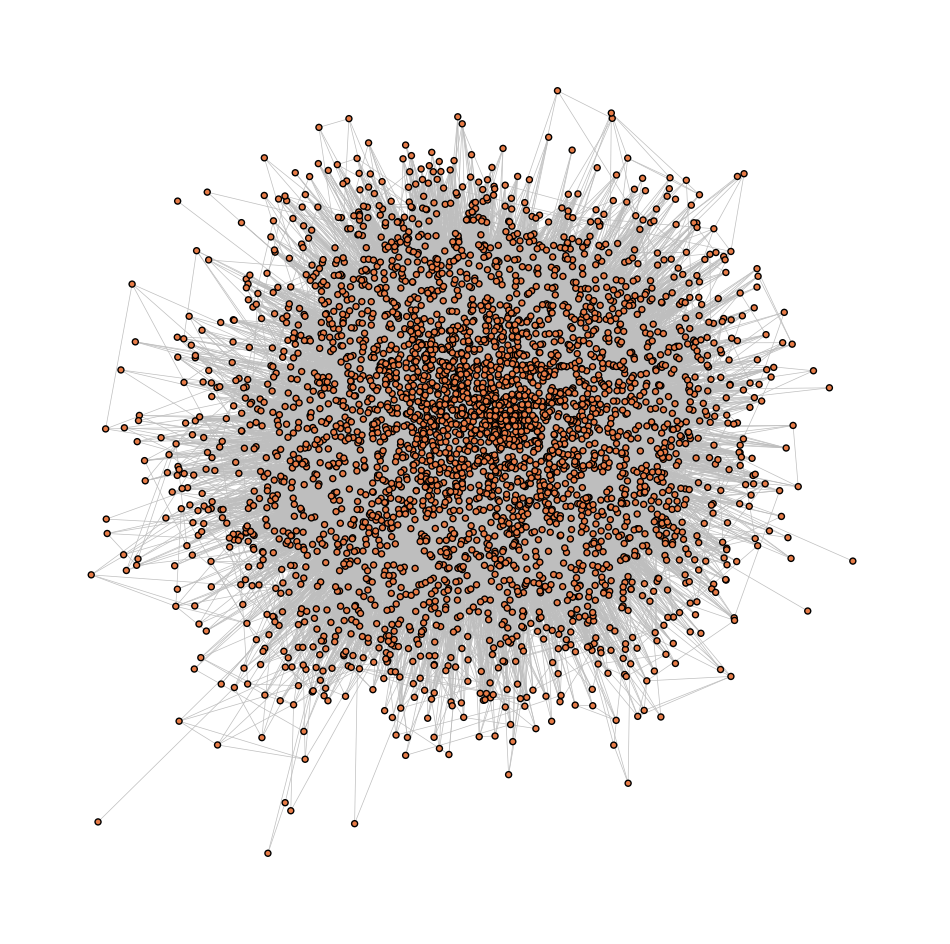

In [6]:
# Visualize the graph
layout = graph.layout_fruchterman_reingold(niter=1000)

fig, ax = plt.subplots(figsize=(12, 12))

ig.plot(
    graph,
    target=ax,
    layout=layout,
    vertex_size=6,
    vertex_label=None,
    vertex_color="#E87C47",
    edge_width=0.5,
    edge_color="gray",
)

plt.show()

In [7]:
Sigma(graph)

Sigma(ig.Graph with 3,611 nodes and 130,439 edges)

## Statistics

#### 1. Vertex Degree Distribution

,degree,vertex_count
0,1,4
1,2,13
2,3,46
3,4,76
4,5,106


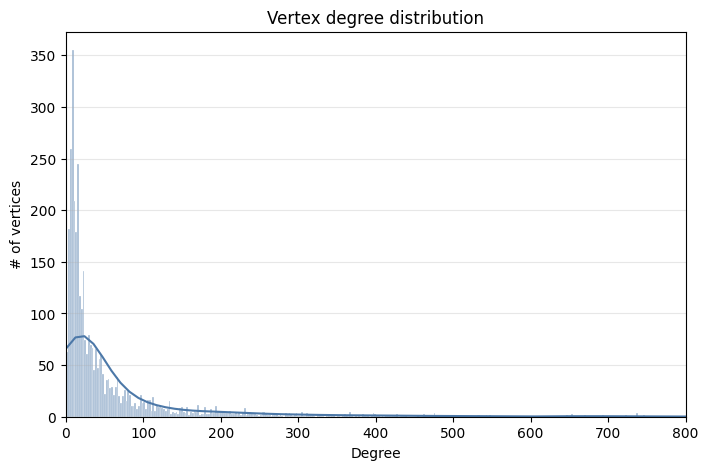

In [ ]:
degrees = graph.degree()

degree_counts = pd.Series(degrees).value_counts().sort_index()
degree_distribution = pd.DataFrame({
    "degree": degree_counts.index,
    "vertex_count": degree_counts.values,
})
display(degree_distribution.head())

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    degrees,
    bins=1000,
    kde=True,
    stat="count",
    color="#4C78A8",
    edgecolor="white",
    linewidth=0.2,
    ax=ax,
)
ax.set_title("Vertex degree distribution")
ax.set_xlabel("Degree")
ax.set_ylabel("Number of vertices")
ax.set_xlim(left=0, right=800)
ax.grid(axis="y", alpha=0.3)

plt.show()

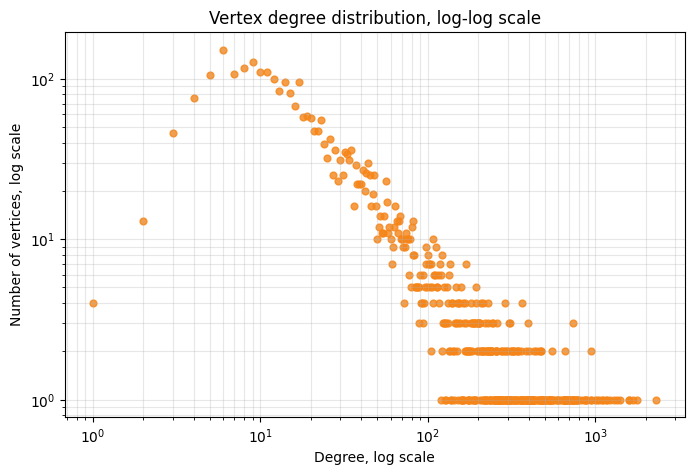

In [ ]:
positive_degree_distribution = degree_distribution[degree_distribution["degree"] > 0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    positive_degree_distribution["degree"],
    positive_degree_distribution["vertex_count"],
    s=24,
    alpha=0.8,
    color="#F58518",
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Vertex degree distribution, log-log scale")
ax.set_xlabel("Degree, log scale")
ax.set_ylabel("Number of vertices, log scale")
ax.grid(True, which="both", alpha=0.3)

plt.show()

In [53]:
degrees = [d for d in graph.degree() if d > 0]

fit = powerlaw.Fit(degrees, discrete=True)
print("xmin:", fit.power_law.xmin)
print("alpha:", fit.power_law.alpha)

R, p = fit.distribution_compare("power_law", "lognormal")
print("power-law vs lognormal:", R, p)

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 427/427 [00:00<00:00, 1314.24it/s]

xmin: 192.0
alpha: 2.6127500556032066
power-law vs lognormal: -7.837429463206794 0.01358152249285974


#### Clustering Coefficients

In [81]:
clustering_graph = graph.as_undirected() if graph.is_directed() else graph

global_clustering = clustering_graph.transitivity_undirected()
average_local_clustering = clustering_graph.transitivity_avglocal_undirected(mode="zero")
local_clustering = clustering_graph.transitivity_local_undirected(mode="zero")

print("Global clustering coefficient:", global_clustering)
print("Average local clustering coefficient:", average_local_clustering)

clustering_by_vertex = pd.DataFrame({
    "ingredient": clustering_graph.vs["_nx_name"],
    "degree": clustering_graph.degree(),
    "clustering_coefficient": local_clustering,
})

display(
    clustering_by_vertex
    .sort_values(["clustering_coefficient", "degree"], ascending=[False, False])
    .head(10)
)

Global clustering coefficient: 0.21953796667757247
Average local clustering coefficient: 0.7550503733770968


,ingredient,degree,clustering_coefficient
2661,dal,34,1.0
3156,asafoetida powder,34,1.0
235,sourdough,32,1.0
2603,dukkah,32,1.0
3203,annatto,30,1.0
170,sweet italian pork sausage,28,1.0
1897,barramundi,25,1.0
2791,dried date,25,1.0
270,medium curry powder,24,1.0
1045,dark turkey meat,24,1.0


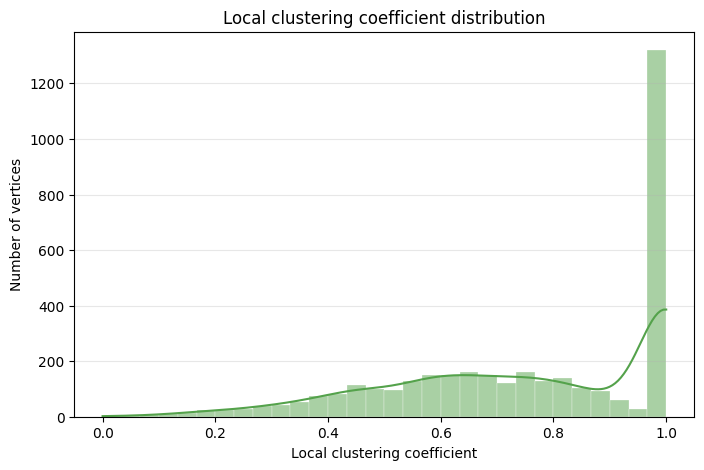

In [82]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    clustering_by_vertex["clustering_coefficient"],
    bins=30,
    kde=True,
    color="#54A24B",
    edgecolor="white",
    linewidth=0.2,
    ax=ax,
)
ax.set_title("Local clustering coefficient distribution")
ax.set_xlabel("Local clustering coefficient")
ax.set_ylabel("Number of vertices")
ax.grid(axis="y", alpha=0.3)

plt.show()

#### Community Detection

In [84]:
def parse_counter_attr(value):
    if isinstance(value, dict):
        return Counter(value)
    if value is None or value == "":
        return Counter()
    return Counter(ast.literal_eval(value))

def parse_cuisines(x):
    if isinstance(x, dict):
        return x
    return ast.literal_eval(x)

In [ ]:
def add_pmi_edge_weights(graph_nx, total_recipe_count, count_weight="recipe_count"):
    graph_with_pmi = graph_nx.copy()

    for u, v, attrs in graph_with_pmi.edges(data=True):
        pair_count = float(attrs[count_weight])  # num of pairs (u, v)
        u_count = float(graph_with_pmi.nodes[u][count_weight])  # num of recipes with an ingredient u
        v_count = float(graph_with_pmi.nodes[v][count_weight])  # num of recipes with an ingredient v

        pmi = math.log((pair_count * total_recipe_count) / (u_count * v_count))
        attrs["pmi"] = pmi
        attrs["positive_pmi"] = max(pmi, 0)

    return graph_with_pmi

In [ ]:
def sparsify_top_k(graph_nx, top_k=10, weight="positive_pmi", min_weight=0):
    sparse_nx = nx.Graph()
    sparse_nx.add_nodes_from(graph_nx.nodes(data=True))

    edges_to_keep = set()
    for node in graph_nx.nodes:
        neighbors = sorted(
            graph_nx[node].items(),
            key=lambda item: float(item[1].get(weight, 1)),
            reverse=True,
        )
        selected_neighbors = neighbors if top_k is None or top_k <= 0 else neighbors[:top_k]

        for neighbor, edge_attrs in selected_neighbors:
            if float(edge_attrs[weight]) >= min_weight:
                edges_to_keep.add(frozenset((node, neighbor)))

    for u, v, edge_attrs in graph_nx.edges(data=True):
        if frozenset((u, v)) in edges_to_keep:
            edge_attrs = edge_attrs.copy()
            edge_attrs[weight] = float(edge_attrs[weight])
            sparse_nx.add_edge(u, v, **edge_attrs)

    return sparse_nx

In [ ]:
total_recipe_count = int(graph_nx.graph.get("total_recipes", 7034))

edge_weight_name = "positive_pmi"
pmi_graph_nx = add_pmi_edge_weights(graph_nx, total_recipe_count)
pmi_graph = ig.Graph.from_networkx(pmi_graph_nx)
pmi_edge_weights = [float(weight) for weight in pmi_graph.es[edge_weight_name]]

In [122]:
top_k_neighbors = None
min_edge_weight = 5
min_component_size = 20

raw_sparse_nx = sparsify_top_k(pmi_graph_nx, top_k=top_k_neighbors, weight=edge_weight_name, min_weight=min_edge_weight)

large_components = [
    component
    for component in nx.connected_components(raw_sparse_nx)
    if len(component) >= min_component_size
]
nodes_to_keep = set().union(*large_components) if large_components else set(raw_sparse_nx.nodes)

sparse_nx = raw_sparse_nx.subgraph(nodes_to_keep).copy()
pmi_core_nx = pmi_graph_nx.subgraph(nodes_to_keep).copy()
pmi_core_graph = ig.Graph.from_networkx(pmi_core_nx)
pmi_core_edge_weights = [float(weight) for weight in pmi_core_graph.es[edge_weight_name]]

sparse_graph = ig.Graph.from_networkx(sparse_nx)
edge_weights = [float(weight) for weight in sparse_graph.es[edge_weight_name]]

print("Original graph:", graph_nx.number_of_nodes(), "nodes,", graph_nx.number_of_edges(), "edges")
print("PMI weight:", edge_weight_name)
print("Raw sparse graph:", raw_sparse_nx.number_of_nodes(), "nodes,", raw_sparse_nx.number_of_edges(), "edges")
print("Removed from small components:", raw_sparse_nx.number_of_nodes() - sparse_nx.number_of_nodes(), "nodes")
print("Sparse graph:", sparse_nx.number_of_nodes(), "nodes,", sparse_nx.number_of_edges(), "edges")
print("Connected components:", nx.number_connected_components(sparse_nx))

Original graph: 3611 nodes, 130439 edges
PMI weight: positive_pmi
Raw sparse graph: 3611 nodes, 8150 edges
Removed from small components: 419 nodes
Sparse graph: 3192 nodes, 8129 edges
Connected components: 1


In [123]:
communities = sparse_graph.community_leiden(
    objective_function="modularity",
    weights=edge_weights,
    n_iterations=-1,
)
membership = communities.membership
sparse_graph.vs["community"] = membership
graph_nx_communities = dict(zip(sparse_graph.vs["_nx_name"], membership))
nx.set_node_attributes(sparse_nx, graph_nx_communities, "community")

print("Communities:", len(communities))
print("Modularity (PMI graph, kept nodes):", pmi_core_graph.modularity(membership, weights=pmi_core_edge_weights))
print("Modularity (sparse graph):", sparse_graph.modularity(membership, weights=edge_weights))

Communities: 30
Modularity (PMI graph, kept nodes): 0.4116950913217194
Modularity (sparse graph): 0.711510175157715


In [124]:
weighted_degree = sparse_graph.strength(weights=edge_weights)
ingredient_communities = pd.DataFrame({
    "ingredient": sparse_graph.vs["_nx_name"],
    "community": membership,
    "degree": sparse_graph.degree(),
    "weighted_degree": weighted_degree,
    "recipe_count": [int(v["recipe_count"]) for v in sparse_graph.vs],
})

global_cuisine_counts = Counter()
for vertex in sparse_graph.vs:
    global_cuisine_counts.update(parse_counter_attr(vertex["cuisines"]))
global_cuisine_total = sum(global_cuisine_counts.values())

community_rows = []
for community_id in sorted(set(membership)):
    vertex_indices = [idx for idx, value in enumerate(membership) if value == community_id]
    community_df = (
        ingredient_communities[ingredient_communities["community"] == community_id]
        .sort_values("weighted_degree", ascending=False)
    )

    cuisine_counts = Counter()
    for vertex_idx in vertex_indices:
        cuisine_counts.update(parse_counter_attr(sparse_graph.vs[vertex_idx]["cuisines"]))

    cuisine_total = sum(cuisine_counts.values())
    dominant_cuisine, dominant_count = cuisine_counts.most_common(1)[0] if cuisine_counts else (None, 0)

    cuisine_lifts = {
        cuisine: (count / cuisine_total) / (global_cuisine_counts[cuisine] / global_cuisine_total)
        for cuisine, count in cuisine_counts.items()
        if cuisine_total > 0 and global_cuisine_counts[cuisine] > 0 and count >= 3
    }
    specific_cuisine, specificity_lift = (
        max(cuisine_lifts.items(), key=lambda item: item[1])
        if cuisine_lifts else (None, float("nan"))
    )

    community_rows.append({
        "community": community_id,
        "size": len(vertex_indices),
        "internal_edges": sparse_graph.subgraph(vertex_indices).ecount(),
        "dominant_cuisine": dominant_cuisine,
        "dominant_cuisine_share": dominant_count / cuisine_total if cuisine_total else 0,
        "specific_cuisine": specific_cuisine,
        "specificity_lift": specificity_lift,
        "central_ingredients": ", ".join(community_df["ingredient"].head(6)),
    })

community_summary = pd.DataFrame(community_rows).sort_values("size", ascending=False).reset_index(drop=True)
display(community_summary)

,community,size,internal_edges,dominant_cuisine,dominant_cuisine_share,specific_cuisine,specificity_lift,central_ingredients
0,0,210,473,asian,0.436747,japanese,6.279781,"gari, pork, tofu, dried shiitake mushrooms, su..."
1,4,205,454,american,0.158789,irish,4.554172,"mascarpone, almond meal, roasted hazelnuts, wh..."
2,12,162,333,american,0.155502,mediterranean,3.416831,"tuna, drain and flake, pimento stuffed olives,..."
3,5,155,284,italian,0.198543,italian,3.547181,"dry red wine, cognac, veal stock, sage leaves,..."
4,23,149,290,american,0.171038,cuban,3.694078,"wheat flour, pomegranate seeds, simple syrup, ..."
5,6,144,404,indian,0.312824,indian,7.417346,"brown cardamom, green cardamom, red chili powd..."
6,19,142,217,asian,0.284946,thai,2.762701,"peanut sauce, cardamom seeds, boston lettuce, ..."
7,10,134,253,mexican,0.290831,mexican,5.613176,"cilantro sprigs, tostadas, queso fresco, groun..."
8,16,131,219,mexican,0.168937,southwestern,4.237050,"fat free milk, cooked chicken breasts, whole w..."
9,13,123,186,mexican,0.212500,mexican,4.101351,"guacamole, bread slices, crackers, shredded le..."


,metric,value
0,nodes,3192.000000
1,edges,8129.000000
2,communities,30.000000
3,modularity,0.711510
4,community_assortativity,0.719912
5,degree_assortativity,0.107670
6,global_clustering,0.224896
7,average_local_clustering,0.237993
8,mean_conductance,0.241388


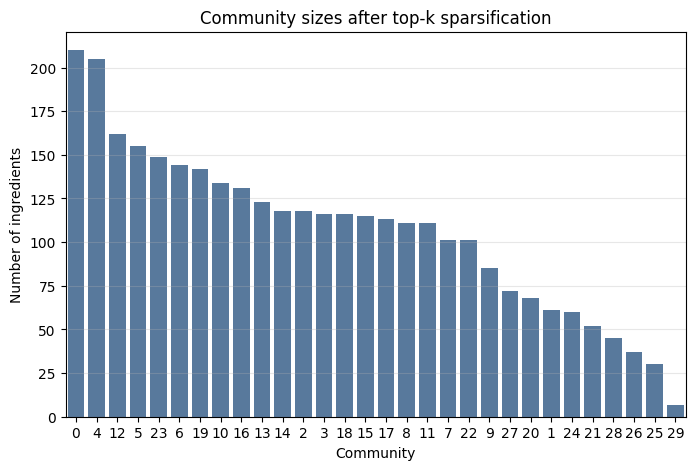

In [125]:
community_conductance = []
for community in communities:
    community_names = set(sparse_graph.vs[community]["_nx_name"])
    if 0 < len(community_names) < sparse_nx.number_of_nodes():
        community_conductance.append(conductance(sparse_nx, community_names, weight=edge_weight_name))

validation_metrics = pd.DataFrame([
    {"metric": "nodes", "value": sparse_graph.vcount()},
    {"metric": "edges", "value": sparse_graph.ecount()},
    {"metric": "communities", "value": len(communities)},
    {"metric": "modularity", "value": sparse_graph.modularity(membership, weights=edge_weights)},
    {"metric": "community_assortativity", "value": sparse_graph.assortativity_nominal(membership, directed=False)},
    {"metric": "degree_assortativity", "value": sparse_graph.assortativity_degree(directed=False)},
    {"metric": "global_clustering", "value": sparse_graph.transitivity_undirected()},
    {"metric": "average_local_clustering", "value": sparse_graph.transitivity_avglocal_undirected(mode="zero")},
    {"metric": "mean_conductance", "value": sum(community_conductance) / len(community_conductance)},
])
display(validation_metrics)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=community_summary,
    x="community",
    y="size",
    order=community_summary["community"],
    color="#4C78A8",
    ax=ax,
)
ax.set_title("Community sizes after top-k sparsification")
ax.set_xlabel("Community")
ax.set_ylabel("Number of ingredients")
ax.grid(axis="y", alpha=0.3)

plt.show()

In [126]:
# Visualize PMI-based communities
sparse_graph.vs["label"] = sparse_graph.vs["_nx_name"]
sparse_graph.vs["weighted_degree"] = weighted_degree
sparse_graph.es["pmi_label"] = [round(float(value), 2) for value in sparse_graph.es["pmi"]]

Sigma(
    sparse_graph,
    node_color="community",
    node_size="weighted_degree",
    node_label="label",
    edge_size=edge_weight_name,
    edge_label="pmi_label",
    clickable_edges=True,
)

Sigma(ig.Graph with 3,192 nodes and 8,129 edges)

#### Edge Betweenness and Girvan–Newman Algorithm

In [129]:
# Bridges between Leiden communities
bridge_graph_nx = sparse_nx.copy()

weighted_degree_by_ingredient = dict(
    zip(ingredient_communities["ingredient"], ingredient_communities["weighted_degree"])
)
community_to_dominant_cuisine = dict(
    zip(community_summary["community"], community_summary["dominant_cuisine"])
)

for node, attrs in bridge_graph_nx.nodes(data=True):
    attrs["label"] = node
    attrs["weighted_degree"] = float(weighted_degree_by_ingredient.get(node, 0))

for u, v, attrs in bridge_graph_nx.edges(data=True):
    pmi_weight = float(attrs[edge_weight_name])
    attrs["distance"] = 1 / pmi_weight if pmi_weight > 0 else float("inf")
    attrs["pmi_label"] = round(float(attrs["pmi"]), 2)

betweenness_sample_size = min(300, bridge_graph_nx.number_of_nodes())
min_bridge_recipe_count = 2
edge_betweenness = nx.edge_betweenness_centrality(
    bridge_graph_nx,
    k=betweenness_sample_size,
    weight="distance",
    seed=42,
)

bridge_rows = []
for u, v, attrs in bridge_graph_nx.edges(data=True):
    u_community = bridge_graph_nx.nodes[u]["community"]
    v_community = bridge_graph_nx.nodes[v]["community"]

    if u_community == v_community:
        continue
    if int(attrs["recipe_count"]) < min_bridge_recipe_count:
        continue

    bridge_rows.append({
        "ingredient_1": u,
        "ingredient_2": v,
        "community_1": u_community,
        "community_2": v_community,
        "dominant_cuisine_1": community_to_dominant_cuisine.get(u_community),
        "dominant_cuisine_2": community_to_dominant_cuisine.get(v_community),
        "pmi": float(attrs["pmi"]),
        "positive_pmi": float(attrs[edge_weight_name]),
        "recipe_count": int(attrs["recipe_count"]),
        "edge_betweenness": edge_betweenness.get((u, v), edge_betweenness.get((v, u))),
    })

bridge_edges = pd.DataFrame(bridge_rows).sort_values("edge_betweenness", ascending=False).reset_index(drop=True)
display(bridge_edges.head(30))

,ingredient_1,ingredient_2,community_1,community_2,positive_pmi,recipe_count,edge_betweenness
0,soft shelled crabs,evaporated milk,28,4,5.362003,2,0.006378
1,thai green curry paste,turkey mince,21,7,5.968139,1,0.005049
2,lime zest,coconut butter,24,5,5.332150,1,0.005032
3,tomato ketchup,white poppy seeds,7,6,7.066751,1,0.004724
4,beef shoulder roast,sauerkraut,14,17,5.600414,2,0.004295
5,dole pineapple tidbits,tomato ketchup,16,7,7.066751,1,0.004143
6,papaya,long beans,6,15,5.862779,1,0.004032
7,turkey,hot smoked paprika,20,17,5.051848,1,0.003990
8,crushed garlic,seitan,17,18,5.680457,1,0.003912
9,coffee,piloncillo,4,10,5.274992,1,0.003857


In [132]:
# Girvan-Newman on a compact bridge backbone
top_bridge_edges = bridge_edges.head(75)
bridge_nodes = set(top_bridge_edges["ingredient_1"]) | set(top_bridge_edges["ingredient_2"])

top_nodes_per_community = (
    ingredient_communities
    .sort_values("weighted_degree", ascending=False)
    .groupby("community")
    .head(8)["ingredient"]
)
backbone_nodes = bridge_nodes | set(top_nodes_per_community)

gn_graph_nx = bridge_graph_nx.subgraph(backbone_nodes).copy()
gn_graph_nx.remove_nodes_from(list(nx.isolates(gn_graph_nx)))

In [133]:
def pmi_most_valuable_edge(graph):
    edge_scores = nx.edge_betweenness_centrality(graph, weight="distance")
    return max(edge_scores, key=edge_scores.get)

In [ ]:
max_girvan_newman_steps = 4
girvan_newman_rows = []
best_partition = None
best_modularity = float("-inf")

girvan_newman_partitions = nx.community.girvan_newman(gn_graph_nx, most_valuable_edge=pmi_most_valuable_edge)



### 1.2 Small and Giant Components

In [8]:
components = graph.connected_components(mode="weak")
giant_component = components.giant()
small_components = [c for c in components if len(c) < 20]

print("Original:", f"{graph.vcount()} vertices, {graph.ecount()} edges")
print("Giant:", f"{giant_component.vcount()} ({round(100 * giant_component.vcount() / graph.vcount(), 2)}% of total) vertices, {giant_component.ecount()} edges")

Original: 3611 vertices, 130439 edges
Giant: 3611 (100.0% of total) vertices, 130439 edges


In [9]:
vertices_small = []

for component in small_components:
    for v in component:
        print(v, graph.vs[v]["_nx_name"])
        vertices_small.append(v)
        # print(v, graph_nx.nodes[v])

In [10]:
# print(graph_nx.nodes)
print(graph.vertex_attributes())

['_nx_name', 'recipe_count', 'cuisines', 'courses', 'time_groups']


In [11]:
graph.vs[1320]["cuisines"]

'{"japanese": 3, "asian": 3}'

### 1.3 Ingredients Specific for One Cuisine

In [13]:
cuisine_totals = Counter()
total_count = 0

for v_idx, v in enumerate(graph.vs):
    cuisines = parse_cuisines(v["cuisines"])

    if not cuisines:
        continue

    for cuisine, count in cuisines.items():
        cuisine_totals[cuisine] += count
        total_count += count

# P(cuisine)
p_cuisine = {
    cuisine: count / total_count
    for cuisine, count in cuisine_totals.items()
}

In [63]:
selected_vertices = []
dominant_cuisines = []
dominant_lifts = []

for v_idx, v in enumerate(graph.vs):
    cuisines = parse_cuisines(v["cuisines"])
    ingredient_total = sum(cuisines.values())

    if not cuisines or v_idx in vertices_small or ingredient_total < 10:
        continue

    lifts = {}

    for cuisine, count in cuisines.items():
        # P(cuisine | ingredient)
        p_cuisine_given_ingredient = count / ingredient_total
        # lift = P(cuisine | ingredient) / P(cuisine)
        lifts[cuisine] = p_cuisine_given_ingredient / p_cuisine[cuisine]

    max_lift = max(lifts.values())
    if max_lift <= 20:
        continue

    winners = [cuisine for cuisine, lift_value in lifts.items() if lift_value == max_lift]
    print("Ingredient:", v["_nx_name"], "| Cuisine:", winners[0])

    if len(winners) == 1:
        selected_vertices.append(v.index)
        dominant_cuisines.append(winners[0])
        dominant_lifts.append(max_lift)

dominant_cuisine_lifts = {}

for cuisine, lift in zip(dominant_cuisines, dominant_lifts):
    dominant_cuisine_lifts.setdefault(cuisine, []).append(lift)

Ingredient: preserved lemon | Cuisine: moroccan
Ingredient: cream of mushroom soup | Cuisine: kid-friendly
Ingredient: softened butter | Cuisine: swedish
Ingredient: harissa | Cuisine: moroccan
Ingredient: vanilla beans | Cuisine: french
Ingredient: whole grain mustard | Cuisine: german
Ingredient: parsnips | Cuisine: english
Ingredient: almond extract | Cuisine: swedish
Ingredient: almond meal | Cuisine: french
Ingredient: fresh pineapple | Cuisine: hawaiian
Ingredient: extra lean ground beef | Cuisine: english
Ingredient: pie dough | Cuisine: english
Ingredient: chourico | Cuisine: portuguese
Ingredient: dark chocolate | Cuisine: french
Ingredient: ghee | Cuisine: indian
Ingredient: pecans | Cuisine: swedish
Ingredient: baking soda | Cuisine: irish
Ingredient: cooking wine | Cuisine: chinese
Ingredient: condensed cream of mushroom soup | Cuisine: kid-friendly
Ingredient: prepared horseradish | Cuisine: swedish
Ingredient: cocoa powder | Cuisine: english
Ingredient: coriander powder |

In [71]:
dominance_count = Counter(dominant_cuisines)

cuisine_dominance_stats = pd.DataFrame([
    {
        "cuisine": cuisine,
        "dominance_count": dominance_count.get(cuisine, 0),
        "overall_cuisine_count": cuisine_totals[cuisine],
        "dominance_percent": 100 * dominance_count.get(cuisine, 0) / cuisine_totals[cuisine],
        "mean_dominant_lift": (
            sum(dominant_cuisine_lifts.get(cuisine, [])) / len(dominant_cuisine_lifts[cuisine])
            if cuisine in dominant_cuisine_lifts else 0
        ),
    }
    for cuisine in sorted(cuisine_totals)
])

cuisine_dominance_stats = cuisine_dominance_stats.sort_values("dominance_percent", ascending=False).reset_index(drop=True)

cuisine_dominance_stats.head(10)

,cuisine,dominance_count,overall_cuisine_count,dominance_percent,mean_dominant_lift
0,english,15,180,8.333333,35.937050
1,kid-friendly,5,625,0.800000,26.047584
2,hawaiian,9,1518,0.592885,31.186188
3,swedish,6,1382,0.434153,28.865678
4,irish,6,1569,0.382409,37.991361
5,moroccan,5,2260,0.221239,34.764580
6,french,6,2756,0.217707,24.158375
7,indian,4,3717,0.107614,21.280853
8,german,2,2315,0.086393,23.453197
9,portuguese,2,2487,0.080418,24.244203


In [66]:
h = graph.subgraph(selected_vertices)
h.vs["dominant_cuisine"] = dominant_cuisines
h.vs["dominant_lift"] = dominant_lifts

selected_ingredient_names = [graph.vs[v]["_nx_name"] for v in selected_vertices]
h_nx = graph_nx.subgraph(selected_ingredient_names).copy()

for ingredient, cuisine, lift in zip(selected_ingredient_names, dominant_cuisines, dominant_lifts):
    h_nx.nodes[ingredient]["dominant_cuisine"] = cuisine
    h_nx.nodes[ingredient]["dominant_lift"] = lift
    h_nx.nodes[ingredient]["label"] = ingredient


# h_components = h.connected_components(mode="weak")
# h_giant = h_components.giant()

# print("Selected vertices:", h_giant.vcount())
# print("Edges:", h_giant.ecount())

In [ ]:
unique_cuisines = sorted(set(dominant_cuisines))
palette = ig.RainbowPalette(n=len(unique_cuisines))
color_map = {cuisine: palette[i] for i, cuisine in enumerate(unique_cuisines)}
vertex_colors = [color_map[cuisine] for cuisine in dominant_cuisines]

In [127]:
Sigma(
    h,
    node_color="dominant_cuisine", node_size="dominant_lift", node_label="label",
    edge_size="recipe_count", edge_label="recipe_count", clickable_edges=True
)

Sigma(ig.Graph with 69 nodes and 140 edges)